In [1]:
# %pip install -q langgraph-supervisor langchain-tavily


In [2]:
# lets load variables in .env 
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# initialize the chat model
from langchain.chat_models import init_chat_model
llm = init_chat_model("gemini-2.5-flash", model_provider="google_vertexai")

In [4]:
# Lets create a web_search_agent
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=2)

In [5]:
results = web_search_tool.invoke("Who won IPL 2025?")
results

{'query': 'Who won IPL 2025?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': "Yesterday's IPL Match Result: Who won IPL 2025 crown last night, RCB or ...",
   'url': 'https://economictimes.indiatimes.com/news/sports/yesterdays-ipl-match-result-who-won-ipl-2025-crown-last-night-rcb-or-pbks-narendra-modi-stadium-hosts-one-for-the-history-books/articleshow/121609813.cms',
   'content': "Royal Challengers Bengaluru defeated Punjab Kings in a thrilling IPL 2025 final. RCB secured their first-ever IPL title after an 18-year wait. The match went down to the wire, with RCB winning by 6 runs. Krunal Pandya was named Man of the Match for his economical bowling. Shashank Singh's brilliant knock went in vain.",
   'score': 0.9253988,
   'raw_content': None},
  {'title': 'Who won IPL 2025? What happened in the final between RCB and PBKS?',
   'url': 'https://www.sportingnews.com/in/ipl/news/who-won-ipl-2025-what-happened-final-rcb-pbks/66f5c418beb57649f8a6b6bb

In [8]:
system_message_prompt_research = "You are a research agent. Instructions: only assist with research kind of topics dont do anything logical such as math, Respond only with results of your work"


In [9]:
from IPython.display import display, Image
def display_graph(agent):
    display(Image(agent.get_graph().draw_mermaid_png()))

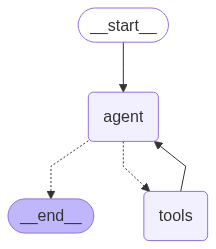

In [10]:
# lets create  areact agent for websearch
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage

web_search_agent = create_react_agent(
    model=llm,
    tools=[web_search_tool],
    prompt=SystemMessage(content = system_message_prompt_research),
    name = "web_research_agent"
)
display_graph(web_search_agent)

In [11]:
from langchain_core.messages import HumanMessage
result = web_search_agent.invoke({
    "messages": [HumanMessage(content="who won IPL 2024?")]
})

In [12]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

who won IPL 2024?
================================== Ai Message ==================================
Name: web_research_agent
Tool Calls:
  tavily_search (085c019f-be01-4edf-a930-2071eebe9a43)
 Call ID: 085c019f-be01-4edf-a930-2071eebe9a43
  Args:
    query: who won IPL 2024?
================================= Tool Message =================================
Name: tavily_search

{"query": "who won IPL 2024?", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "2024 Indian Premier League final - Wikipedia", "url": "https://en.wikipedia.org/wiki/2024_Indian_Premier_League_final", "content": "^ _**a**__**b**__**c**_\"IPL 2024 final result: Kolkata Knight Riders beat Sunrisers Hyderabad to win title\". | Participating Teams | | Group A | * Mumbai Indians * Kolkata Knight Riders * Rajasthan Royals * Delhi Capitals * Lucknow Super Giants | | --- | | Group B | * Sunrisers Hyderabad * Roy

In [13]:
def add(a: int, b: int) -> int:
    """Adds two numbers

    Args:
        a (int): a
        b (int): b

    Returns:
        int: returns a + b
    """
    return a + b

def sub(a: int, b: int) -> int:
    """sub two numbers

    Args:
        a (int): a
        b (int): b

    Returns:
        int: returns a - b
    """
    return a - b

In [14]:
math_agent = create_react_agent(
    model=llm,
    tools=[add, sub],
    prompt=(
        "You are a math agent\n"
        "Instructions\n"
        "Assist only in math related tasks"
        "Respons only with results"
        
    ),
    name="math_agent"
)

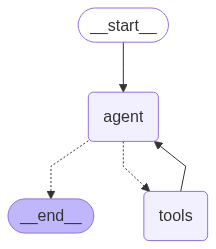

In [15]:
display_graph(math_agent)

In [16]:
from langchain_core.messages import HumanMessage
result = math_agent.invoke({
    "messages": [HumanMessage(content = "what is 30 plus 20?")]
})

In [17]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is 30 plus 20?
================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (0ea308f3-d82b-476f-94c1-a60b7c4349d7)
 Call ID: 0ea308f3-d82b-476f-94c1-a60b7c4349d7
  Args:
    b: 20.0
    a: 30.0
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================
Name: math_agent

50


In [18]:
# Creating a supervisor agent
from langgraph_supervisor import create_supervisor
supervisor = create_supervisor(
    model=llm,
    agents=[web_search_agent, math_agent],
    prompt=(
        "You are a supervisor managing two agents \n"
        " - web_search agent. Assign search or research related tasks to this agent \n"
        " - math agent, Assing math related tasks to this agent \n"
        "Assign work to one agent at a time, do not call agents in parallel \n"
        "Do not work yourself"
    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile()

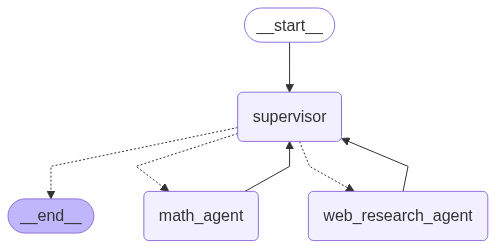

In [19]:
display_graph(supervisor)


In [20]:
for chunk in supervisor.stream(
    {
        "messages": [
            HumanMessage(content="Find the revenue of Tesla and add it to revenue of SpaceX")
        ]
    }
):
    
    print(chunk)

Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel is_last_step, ignoring it.
Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel remaining_steps, ignoring it.


{'supervisor': {'messages': [HumanMessage(content='Find the revenue of Tesla and add it to revenue of SpaceX', additional_kwargs={}, response_metadata={}, id='d4013662-be38-4a38-8b65-da6474fa53d2'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'transfer_to_web_research_agent', 'arguments': '{}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 111, 'candidates_token_count': 9, 'total_token_count': 289, 'prompt_tokens_details': [{'modality': 1, 'token_count': 111}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 9}], 'thoughts_token_count': 169, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -5.476976606580946, 'model_name': 'gemini-2.5-flash'}, name='supervisor', id='run--cb1b9d50-14c9-4ca7-b64f-7a4a18f3ec1b-0', tool_calls=[{'name': 'transfer_to_web_research_agent', 'args': {}, 'id': 'f0a1cd0e-c9ba-45b5-9daa-e816dc2ed0e3', 'type': 'tool_cal

In [22]:
response = supervisor.invoke(
    {
        "messages": [
            HumanMessage(content="Find the revenue of Tesla and add it revenue of SpaceX")
        ]
    }
)

Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel is_last_step, ignoring it.
Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel remaining_steps, ignoring it.


In [23]:
response['messages']


[HumanMessage(content='Find the revenue of Tesla and add it revenue of SpaceX', additional_kwargs={}, response_metadata={}, id='a21a4af8-8457-48e5-b304-5dd25cfe41a6'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'transfer_to_web_research_agent', 'arguments': '{}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 110, 'candidates_token_count': 9, 'total_token_count': 318, 'prompt_tokens_details': [{'modality': 1, 'token_count': 110}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 9}], 'thoughts_token_count': 199, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -7.293451097276476, 'model_name': 'gemini-2.5-flash'}, name='supervisor', id='run--977998d5-c294-4964-bd37-299d20c2af22-0', tool_calls=[{'name': 'transfer_to_web_research_agent', 'args': {}, 'id': 'e10ec435-a3ad-42bb-95e3-2f10569dd91e', 'type': 'tool_call'}], usage_metadata={'input_t

In [24]:
response['messages'][-1].pretty_print()


================================== Ai Message ==================================
Name: supervisor

Tesla's annual revenue for 2024 was $97.69 billion. SpaceX's estimated total revenue for 2024 (from launch services and Starlink) was $12.3 billion ($5.5 billion + $6.8 billion).

The combined revenue of Tesla and SpaceX for 2024 is $97.69 billion + $12.3 billion = **$109.99 billion**.
